## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
BLEU, ROUGE = "#2E86AB", "#D62828"

RAW_PATH = "/Users/madeleine/Desktop/ml-poc-project/data/raw/natl2018us.csv"
PROC_DIR = "/Users/madeleine/Desktop/ml-poc-project/data/process"
PLOTS_DIR = "/Users/madeleine/Desktop/ml-poc-project/plots"
os.makedirs(PROC_DIR, exist_ok=True)

## 2. Chargement & Nettoyage Initial

On reprend la logique de filtrage fauit dans l'EDA

In [3]:
COLONNES = {
    'mager': 'Age_Mere', 'bmi': 'IMC_Mere', 'cig_0': 'Tabac_Avant',
    'cig_1': 'Tabac_Trim1', 'precare': 'Mois_Debut_Suivi', 'previs': 'Nb_Visites',
    'wic': 'Aide_WIC', 'rf_phype': 'H_Chronique', 'rf_pdiab': 'D_Chronique',
    'pay': 'Assurance', 'wtgain': 'Prise_Poids', 'ab_nicu': 'Target'
}

df = pd.read_csv(RAW_PATH, usecols=list(COLONNES.keys()), nrows=100_000)
df = df.rename(columns=COLONNES)

df = df[df['Target'].isin(['Y', 'N'])].copy()
df['Target'] = df['Target'].map({'Y': 1, 'N': 0})

# 3. Feature Engineering

Création de nouvelles variables métier pour enrichir le modèle.

In [4]:
# 1. Evolution du tabac (Réduction ou augmentation au T1)
df['Evol_Tabac'] = df['Tabac_Trim1'] - df['Tabac_Avant']

# 2. Suivi précoce (Binaire : a commencé au 1er trimestre ?)
# precare 1,2,3 = T1. 99 = Inconnu (sera géré après)
df['Suivi_T1'] = df['Mois_Debut_Suivi'].apply(lambda x: 1 if x <= 3 else 0)

print(f"Nouvelles features créées. Taille actuelle : {df.shape}")

Nouvelles features créées. Taille actuelle : (99900, 14)


# 4. Traitement des Valeurs Sentinelles

Le CDC utilise 99/99.9 pour désigner l'inconnu. Les transformer en NaN est vital avant le Scaling.

In [10]:
sentinelles = {
    'IMC_Mere': 99.9, 'Prise_Poids': 99, 'Tabac_Avant': 99,
    'Tabac_Trim1': 99, 'Mois_Debut_Suivi': 99, 'Nb_Visites': 99, 'Assurance': 9
}

for col, val in sentinelles.items():
    df[col] = df[col].replace(val, np.nan)

from skrub import TableReport

TableReport(df)

Processing column  14 / 14


,,,,,,,,,,,,,,


# 5. Pipeline d'Encodage et Scaling

Utilisation de ColumnTransformer pour isoler les traitements numériques et catégoriels.

In [11]:
X = df.drop(columns=['Target'])
y = df['Target']

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Pipeline Numérique : Imputation médiane + Standardisation
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline Catégoriel : Imputation mode + OneHot
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features)
])

X_scaled = preprocessor.fit_transform(X)
print(f"Dimensions après encodage (OHE) : {X_scaled.shape}")

Dimensions après encodage (OHE) : (99900, 19)


# 6. Réduction de Dimension (PCA)

On cherche à réduire le bruit tout en conservant 95% de la variance.

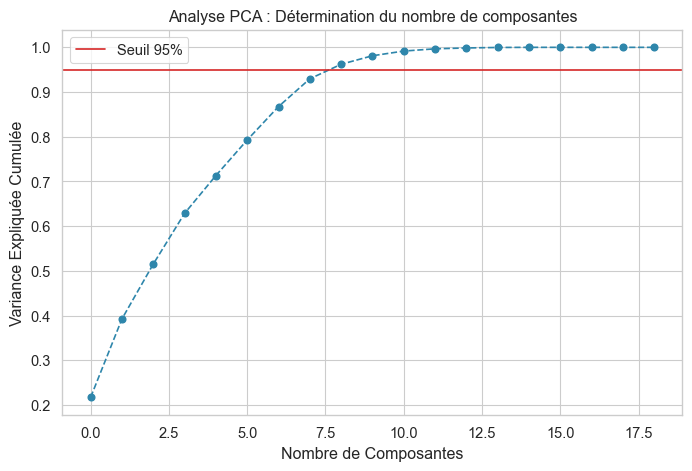

Nombre de composantes retenues pour 95% de variance : 9


In [12]:
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Graphique de la variance expliquée cumulée
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color=BLEU)
plt.axhline(y=0.95, color=ROUGE, linestyle='-', label='Seuil 95%')
plt.xlabel('Nombre de Composantes')
plt.ylabel('Variance Expliquée Cumulée')
plt.title('Analyse PCA : Détermination du nombre de composantes')
plt.legend()
plt.savefig(f"{PLOTS_DIR}/preprocessing_pca_variance.png")
plt.show()

# Application de la PCA finale
n_comp = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
pca_final = PCA(n_components=n_comp)
X_final = pca_final.fit_transform(X_scaled)

print(f"Nombre de composantes retenues pour 95% de variance : {n_comp}")

# 7. Sauvegarde du Dataset Processé

In [8]:
# Conversion en DataFrame pour la sauvegarde
cols_pca = [f'PC{i+1}' for i in range(n_comp)]
df_processed = pd.DataFrame(X_final, columns=cols_pca)
df_processed['Target_Risk'] = y.values

# Sauvegarde
output_path = f"{PROC_DIR}/processed_data_pca.csv"
df_processed.to_csv(output_path, index=False)